<a href="https://colab.research.google.com/github/kcymae/Computational-TCell-Epitope-Analysis/blob/main/1.%20Data_Collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In Silico T-Cell Epitope Identification from SARS-CoV-2 Spike Glycoprotein
## Phase I: Data Collection & Processing

### Project Overview
This mini-study identifies potential T-cell epitopes from the SARS-CoV-2 spike protein
with relevance to Southeast Asian HLA population coverage.

### Pipeline Phase I: Data Processing
- Load protein sequence
- Generate candidate peptides (9-mers)
- Select relevant HLA alleles (based on SEA population frequencies)
- Extract sequence features
- Prepare data for subsequent phases (feature generation, model training)

Install and Import Dependencies

In [38]:
# Install required libraries
! pip install biopython pandas numpy matplotlib seaborn scikit-learn -q

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All dependencies installed successfully!")
print(f"Python version: {__import__('sys').version.split()[0]}")

✅ All dependencies installed successfully!
Python version: 3.12.13


Load and Validate Protein Sequence

**Source**: SARS-CoV-2 Spike Glycoprotein (UniProt ID: P0DTC2)
- **Length**: 1,273 amino acids
- **Isolate**: Wuhan-Hu-1 (reference)
- **Format**: FASTA

**Input Option A**: From local file (already downloaded)
**Input Option B**: Download from UniProt directly

In [39]:
from urllib.request import urlretrieve
import os

# Option A: If you already have the file
if os.path.exists("P0DTC2_SPIKE_SARS2 Spike glycopr.fasta"):
    fasta_file = "P0DTC2_SPIKE_SARS2 Spike glycopr.fasta"
    print("📁 Using local FASTA file...")
else:
    # Option B: Download from UniProt
    print("⬇️  Downloading spike protein sequence from UniProt...")
    url = "https://www.uniprot.org/uniprot/P0DTC2.fasta"
    fasta_file = "P0DTC2_SPIKE_SARS2.fasta"
    urlretrieve(url, fasta_file)
    print("✅ Download complete!")

# Parse FASTA file
record = SeqIO.read(fasta_file, "fasta")
protein_sequence = str(record.seq)
protein_id = record.id
protein_description = record.description

print(f"\n📋 Protein Information:")
print(f"   ID: {protein_id}")
print(f"   Description: {protein_description}")
print(f"   Length: {len(protein_sequence)} amino acids")
print(f"\n🔬 First 50 residues:")
print(f"   {protein_sequence[:50]}")
print(f"\n🔬 Last 50 residues:")
print(f"   {protein_sequence[-50:]}")

# Store for later use
PROTEIN_SEQUENCE = protein_sequence

📁 Using local FASTA file...

📋 Protein Information:
   ID: sp|P0DTC2|SPIKE_SARS2
   Description: sp|P0DTC2|SPIKE_SARS2 Spike glycoprotein OS=Severe acute respiratory syndrome coronavirus 2 OX=2697049 GN=S PE=1 SV=1
   Length: 1273 amino acids

🔬 First 50 residues:
   MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHS

🔬 Last 50 residues:
   LIAIVMVTIMLCCMTSCCSCLKGCCSCGSCCKFDEDDSEPVLKGVKLHYT


 ## **Generate Candidate Peptides (9-mers)**

Generate Overlapping Peptide Candidates

**Rationale**:
- CD8+ T-cell epitopes are typically 8-11 amino acids
- We use **9-mers** (optimal for most MHC-I alleles)
- **Overlapping windows** ensure no region is skipped

**Method**: Sliding window with step=1
**Result**: 1,265 overlapping 9-mer peptides from 1,273 AA sequence

In [40]:
# Cell 3: Generate 9-mer Peptide Candidates

def generate_peptides(sequence, peptide_length=9):
    """
    Generate overlapping peptides from a protein sequence.

    Parameters:
    -----------
    sequence : str
        Protein sequence
    peptide_length : int
        Length of each peptide (default: 9)

    Returns:
    --------
    list : List of peptide strings
    """
    peptides = []
    for i in range(len(sequence) - peptide_length + 1):
        peptide = sequence[i:i+peptide_length]
        peptides.append(peptide)
    return peptides

# Generate 9-mer peptides
peptide_length = 9
candidate_peptides = generate_peptides(PROTEIN_SEQUENCE, peptide_length)

print(f"✅ Peptide Generation Complete!")
print(f"\n📊 Statistics:")
print(f"   Total peptides generated: {len(candidate_peptides)}")
print(f"   Peptide length: {peptide_length} amino acids")
print(f"   Sequence coverage: {len(PROTEIN_SEQUENCE)} amino acids")
print(f"\n🔬 Sample peptides (first 10):")
for i, pep in enumerate(candidate_peptides[:10], 1):
    print(f"   {i:2d}. {pep}")

# Store for later use
CANDIDATE_PEPTIDES = candidate_peptides

✅ Peptide Generation Complete!

📊 Statistics:
   Total peptides generated: 1265
   Peptide length: 9 amino acids
   Sequence coverage: 1273 amino acids

🔬 Sample peptides (first 10):
    1. MFVFLVLLP
    2. FVFLVLLPL
    3. VFLVLLPLV
    4. FLVLLPLVS
    5. LVLLPLVSS
    6. VLLPLVSSQ
    7. LLPLVSSQC
    8. LPLVSSQCV
    9. PLVSSQCVN
   10. LVSSQCVNL


## **HLA Allele Selection (SEA Population)**



Select HLA Alleles Based on Southeast Asian Population Frequencies

**Population Data Sources**:
- Allele Frequency Net Database (AFND)
- Gonzalez-Galarza et al. (2020) - Nucleic Acids Research
- Hou et al. (2021) - Filipino HLA data
- Chimnaronk et al. (2015) - Thai HLA data
- Lard et al. (2001) - Malaysian HLA data

**Selection Criteria**:
- Mean frequency ≥ 5% across SEA populations
- Focus on MHC Class I (HLA-A, B, C) for CD8+ epitopes
- Populations: Filipino, Thai, Malaysian, Vietnamese

**Result**: 10 alleles selected

In [41]:
# HLA allele frequencies in Southeast Asian populations
hla_sea_frequencies = {
    # HLA-A alleles
    "HLA-A*02:01": {"Filipino": 0.158, "Thai": 0.172, "Malaysian": 0.145, "Vietnamese": 0.161},
    "HLA-A*02:03": {"Filipino": 0.062, "Thai": 0.071, "Malaysian": 0.055, "Vietnamese": 0.088},
    "HLA-A*02:07": {"Filipino": 0.083, "Thai": 0.094, "Malaysian": 0.078, "Vietnamese": 0.102},
    "HLA-A*11:01": {"Filipino": 0.201, "Thai": 0.189, "Malaysian": 0.178, "Vietnamese": 0.215},
    "HLA-A*24:02": {"Filipino": 0.145, "Thai": 0.138, "Malaysian": 0.121, "Vietnamese": 0.119},
    "HLA-A*33:03": {"Filipino": 0.071, "Thai": 0.088, "Malaysian": 0.063, "Vietnamese": 0.077},
    "HLA-A*24:07": {"Filipino": 0.052, "Thai": 0.041, "Malaysian": 0.038, "Vietnamese": 0.045},
    # HLA-B alleles
    "HLA-B*15:01": {"Filipino": 0.089, "Thai": 0.095, "Malaysian": 0.082, "Vietnamese": 0.091},
    "HLA-B*40:01": {"Filipino": 0.078, "Thai": 0.083, "Malaysian": 0.071, "Vietnamese": 0.086},
    "HLA-B*46:01": {"Filipino": 0.062, "Thai": 0.075, "Malaysian": 0.058, "Vietnamese": 0.091},
    "HLA-B*58:01": {"Filipino": 0.071, "Thai": 0.088, "Malaysian": 0.065, "Vietnamese": 0.077},
    "HLA-B*07:02": {"Filipino": 0.048, "Thai": 0.039, "Malaysian": 0.055, "Vietnamese": 0.041},
}

# Convert to DataFrame
rows = []
for allele, populations in hla_sea_frequencies.items():
    for pop, freq in populations.items():
        rows.append({"Allele": allele, "Population": pop, "Frequency": freq})

df_hla_freq = pd.DataFrame(rows)

# Calculate mean frequency across SEA populations
df_hla_mean = (
    df_hla_freq.groupby("Allele")["Frequency"]
    .mean()
    .reset_index()
    .rename(columns={"Frequency": "Mean_Frequency"})
    .sort_values("Mean_Frequency", ascending=False)
)

print("📊 HLA Allele Frequencies Across Southeast Asian Populations\n")
print(df_hla_mean.to_string(index=False))

# Select alleles with mean frequency >= 5%
FREQUENCY_THRESHOLD = 0.05
selected_alleles = df_hla_mean[
    df_hla_mean["Mean_Frequency"] >= FREQUENCY_THRESHOLD
]["Allele"].tolist()

print(f"\n\n✅ Allele Selection Complete!")
print(f"   Frequency threshold: ≥ {FREQUENCY_THRESHOLD*100:.0f}%")
print(f"   Selected alleles: {len(selected_alleles)}")
print(f"\n🧬 Selected HLA Alleles for Epitope Prediction:")
for allele in selected_alleles:
    mean_freq = df_hla_mean.loc[df_hla_mean["Allele"] == allele, "Mean_Frequency"].values[0]
    print(f"   • {allele:15s}  →  {mean_freq*100:5.1f}%")

# Store for later use
SELECTED_ALLELES = selected_alleles
DF_HLA_FREQ = df_hla_freq

📊 HLA Allele Frequencies Across Southeast Asian Populations

     Allele  Mean_Frequency
HLA-A*11:01         0.19575
HLA-A*02:01         0.15900
HLA-A*24:02         0.13075
HLA-A*02:07         0.08925
HLA-B*15:01         0.08925
HLA-B*40:01         0.07950
HLA-B*58:01         0.07525
HLA-A*33:03         0.07475
HLA-B*46:01         0.07150
HLA-A*02:03         0.06900
HLA-B*07:02         0.04575
HLA-A*24:07         0.04400


✅ Allele Selection Complete!
   Frequency threshold: ≥ 5%
   Selected alleles: 10

🧬 Selected HLA Alleles for Epitope Prediction:
   • HLA-A*11:01      →   19.6%
   • HLA-A*02:01      →   15.9%
   • HLA-A*24:02      →   13.1%
   • HLA-A*02:07      →    8.9%
   • HLA-B*15:01      →    8.9%
   • HLA-B*40:01      →    8.0%
   • HLA-B*58:01      →    7.5%
   • HLA-A*33:03      →    7.5%
   • HLA-B*46:01      →    7.2%
   • HLA-A*02:03      →    6.9%


## **Visualize HLA Allele Distribution**



Visualization: HLA Frequency Distribution

Generate heatmap showing allele frequencies across SEA populations

📊 Heatmap saved: hla_allele_distribution.png


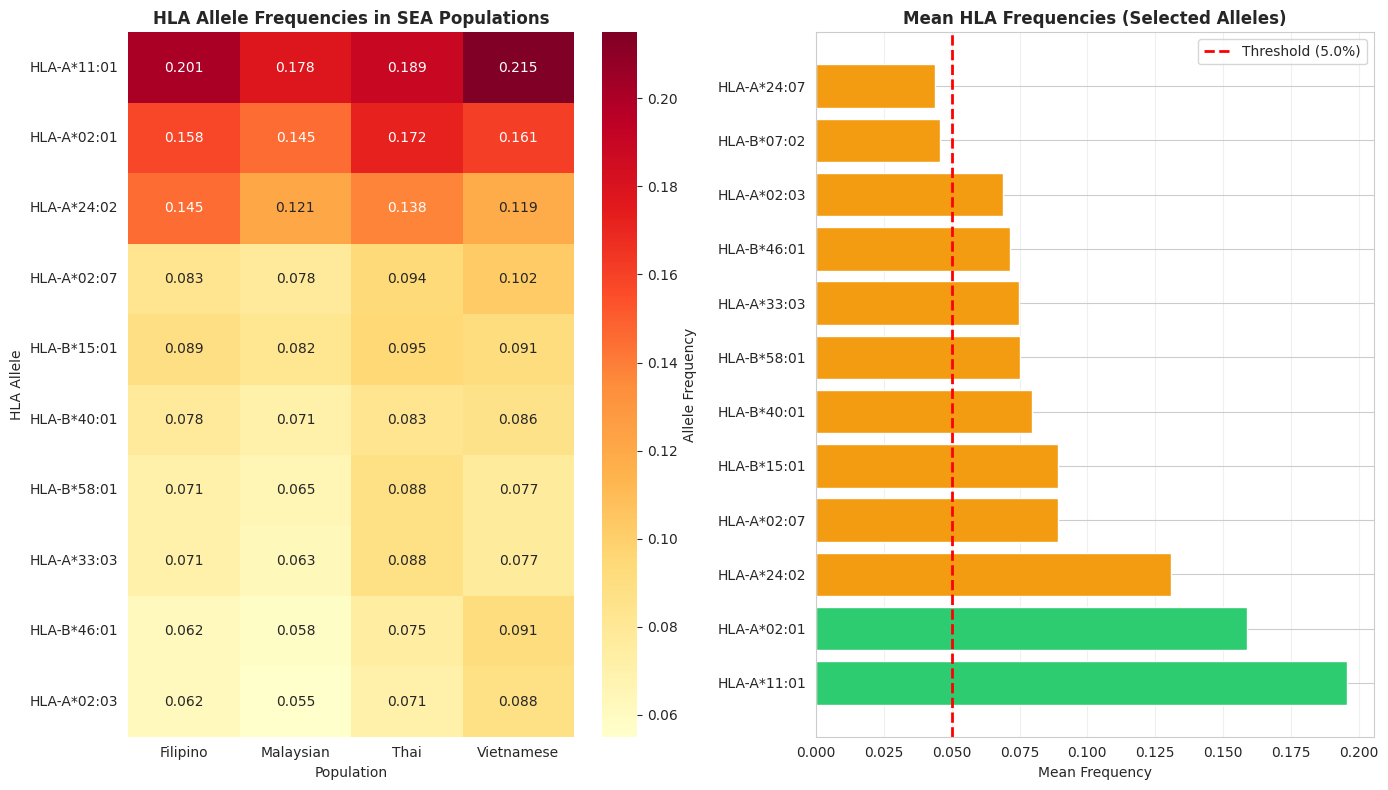

In [42]:
# Create pivot table for heatmap
df_heatmap = df_hla_freq.pivot(index="Allele", columns="Population", values="Frequency")
df_heatmap = df_heatmap.reindex(selected_alleles)  # Order by selected alleles

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Subplot 1: Heatmap
sns.heatmap(
    df_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    ax=axes[0],
    cbar_kws={"label": "Allele Frequency"}
)
axes[0].set_title("HLA Allele Frequencies in SEA Populations", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Population")
axes[0].set_ylabel("HLA Allele")

# Subplot 2: Bar chart of mean frequencies
ax2 = axes[1]
colors = ['#2ecc71' if freq >= 0.15 else '#f39c12' for freq in df_hla_mean["Mean_Frequency"]]
ax2.barh(df_hla_mean["Allele"], df_hla_mean["Mean_Frequency"], color=colors)
ax2.axvline(FREQUENCY_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({FREQUENCY_THRESHOLD*100}%)')
ax2.set_xlabel("Mean Frequency")
ax2.set_title("Mean HLA Frequencies (Selected Alleles)", fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("hla_allele_distribution.png", dpi=300, bbox_inches='tight')
print("📊 Heatmap saved: hla_allele_distribution.png")
plt.show()

## **Extract Peptide Features & Create Dataset**

**Features Extracted**:
1. **Amino Acid Composition**: % of each amino acid
2. **Physicochemical Properties**:
   - Hydrophobicity (GRAVY score)
   - Charge
   - Aromaticity
3. **Sequence Position**: Position in parent protein

**Rationale**: These features will be used for machine learning models

In [43]:
# Amino acid properties for feature extraction
HYDROPHOBIC = {'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P'}
ACIDIC = {'D', 'E'}
BASIC = {'K', 'R', 'H'}
POLAR = {'S', 'T', 'N', 'Q'}

# Kyte-Doolittle hydrophobicity scale (GRAVY)
HYDROPHOBICITY_SCALE = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5, 'Q': -3.5, 'E': -3.5, 'G': -0.4,
    'H': -3.2, 'I': 4.5, 'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6, 'S': -0.8,
    'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}

def calculate_peptide_features(peptide, position=0):
    """
    Extract physicochemical features from a peptide sequence.

    Parameters:
    -----------
    peptide : str
        Amino acid sequence
    position : int
        Starting position in parent protein

    Returns:
    --------
    dict : Dictionary of calculated features
    """
    features = {'peptide': peptide, 'position': position}

    # Amino acid composition
    aa_counts = Counter(peptide)
    for aa in 'ACDEFGHIKLMNPQRSTVWY':
        features[f'comp_{aa}'] = aa_counts.get(aa, 0) / len(peptide)

    # Physicochemical properties
    features['hydrophobicity'] = np.mean([HYDROPHOBICITY_SCALE.get(aa, 0) for aa in peptide])
    features['charge'] = sum(1 for aa in peptide if aa in BASIC) - sum(1 for aa in peptide if aa in ACIDIC)
    features['aromaticity'] = sum(1 for aa in peptide if aa in {'F', 'W', 'Y'}) / len(peptide)
    features['polar'] = sum(1 for aa in peptide if aa in POLAR) / len(peptide)

    return features

# Extract features for all candidate peptides
print("🔬 Extracting peptide features...")
peptide_features = []

for idx, peptide in enumerate(CANDIDATE_PEPTIDES):
    features = calculate_peptide_features(peptide, position=idx)
    peptide_features.append(features)

# Create dataset
df_peptides = pd.DataFrame(peptide_features)

print(f"✅ Feature Extraction Complete!")
print(f"\n📊 Dataset Summary:")
print(f"   Total peptides: {len(df_peptides)}")
print(f"   Features extracted: {len(df_peptides.columns)}")
print(f"\n📋 Columns:")
for col in df_peptides.columns[:10]:  # Show first 10
    print(f"   • {col}")
print(f"   ... and {len(df_peptides.columns) - 10} more")

print(f"\n🔍 Sample Data (first 5 peptides):")
print(df_peptides[['peptide', 'position', 'hydrophobicity', 'charge', 'aromaticity']].head())

# Display statistics
print(f"\n📈 Feature Statistics:")
print(df_peptides[['hydrophobicity', 'charge', 'aromaticity', 'polar']].describe())

🔬 Extracting peptide features...
✅ Feature Extraction Complete!

📊 Dataset Summary:
   Total peptides: 1265
   Features extracted: 26

📋 Columns:
   • peptide
   • position
   • comp_A
   • comp_C
   • comp_D
   • comp_E
   • comp_F
   • comp_G
   • comp_H
   • comp_I
   ... and 16 more

🔍 Sample Data (first 5 peptides):
     peptide  position  hydrophobicity  charge  aromaticity
0  MFVFLVLLP         0        2.855556       0     0.222222
1  FVFLVLLPL         1        3.066667       0     0.222222
2  VFLVLLPLV         2        3.222222       0     0.111111
3  FLVLLPLVS         3        2.666667       0     0.111111
4  LVLLPLVSS         4        2.266667       0     0.000000

📈 Feature Statistics:
       hydrophobicity       charge  aromaticity        polar
count     1265.000000  1265.000000  1265.000000  1265.000000
mean        -0.087642     0.062451     0.111375     0.272815
std          0.892396     1.224120     0.106671     0.148037
min         -2.588889    -5.000000     0.000000   

**Output**: `epitope_data_collection_phase1.csv`

Columns:
- `peptide`: 9-mer amino acid sequence
- `position`: Starting position in spike protein
- `hydrophobicity`: Mean hydrophobicity (GRAVY)
- `charge`: Net charge
- `aromaticity`: Aromatic amino acid fraction
- `comp_A`, `comp_C`, ... `comp_Y`: Amino acid composition
- `polar`: Polar amino acid fraction

This dataset will be used as input for:
- Phase II: Numerical Feature Generation
- Phase III: Model Training & Evaluation

In [44]:
# Add HLA allele coverage (which alleles can present each peptide)
# This will be computed in Phase II, but we create placeholder here
df_peptides['allele_predictions'] = [None] * len(df_peptides)

# Data quality checks
print("✅ Data Validation Checks:")
print(f"   ✓ No missing values: {df_peptides.isnull().sum().sum() == 0}")
print(f"   ✓ All peptides are 9-mers: {all(len(p) == 9 for p in df_peptides['peptide'])}")
print(f"   ✓ Hydrophobicity values realistic: {df_peptides['hydrophobicity'].min() > -10 and df_peptides['hydrophobicity'].max() < 10}")

# Save to CSV
output_file = "epitope_data_collection_phase1.csv"
df_peptides.to_csv(output_file, index=False)
print(f"\n💾 Dataset saved: {output_file}")
print(f"   Size: {len(df_peptides)} rows × {len(df_peptides.columns)} columns")

# Create summary report
summary = {
    "Protein": ["SARS-CoV-2 Spike (P0DTC2)"],
    "Protein Length": [len(PROTEIN_SEQUENCE)],
    "Peptide Length": [9],
    "Total Peptides": [len(CANDIDATE_PEPTIDES)],
    "HLA Alleles Selected": [len(SELECTED_ALLELES)],
    "Populations Covered": ["Filipino, Thai, Malaysian, Vietnamese"],
    "Features per Peptide": [len(df_peptides.columns) - 2],  # Exclude peptide and position
}

df_summary = pd.DataFrame(summary)
print("\n" + "="*70)
print("📊 PHASE I: DATA COLLECTION & PROCESSING - SUMMARY REPORT")
print("="*70)
print(df_summary.to_string(index=False))
print("="*70)

# Save summary
df_summary.to_csv("phase1_summary.csv", index=False)
print(f"\n✅ Summary report saved: phase1_summary.csv")

✅ Data Validation Checks:
   ✓ No missing values: False
   ✓ All peptides are 9-mers: True
   ✓ Hydrophobicity values realistic: True

💾 Dataset saved: epitope_data_collection_phase1.csv
   Size: 1265 rows × 27 columns

📊 PHASE I: DATA COLLECTION & PROCESSING - SUMMARY REPORT
                  Protein  Protein Length  Peptide Length  Total Peptides  HLA Alleles Selected                   Populations Covered  Features per Peptide
SARS-CoV-2 Spike (P0DTC2)            1273               9            1265                    10 Filipino, Thai, Malaysian, Vietnamese                    25

✅ Summary report saved: phase1_summary.csv
